In [1]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [12]:
model = YOLO("../cow_api/utils/new.pt")
cap = cv2.VideoCapture(0)  # ou 0 pour webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break
    # cv2.resize(frame, (480, 640))  # Redimensionner la frame si nécessaire
    results = model(frame, conf=0.7)
    annotated = results[0].plot()
    print(annotated.shape)
    # annotated = cv2.resize(annotated, (frame.shape[1], frame.shape[0]))
    cv2.imshow("Détection museau", annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 (no detections), 53.6ms
Speed: 3.2ms preprocess, 53.6ms inference, 2.2ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 92.0ms
Speed: 3.9ms preprocess, 92.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 143.4ms
Speed: 2.2ms preprocess, 143.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 163.4ms
Speed: 2.2ms preprocess, 163.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 155.6ms
Speed: 2.0ms preprocess, 155.6ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 161.8ms
Speed: 2.7ms preprocess, 161.8ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
(480, 640, 3)

0: 480x640 (no detections), 177.9ms
Speed: 2.2ms preprocess, 177.9ms inference, 2.3ms postprocess per image a


image 1/1 D:\Datasets\our_data\HOL-004\IMG_0972.jpg: 640x480 1 Muzzle, 44.4ms
Speed: 3.4ms preprocess, 44.4ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 480)


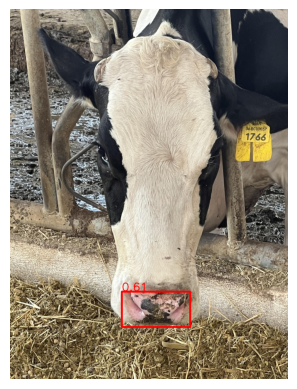

In [12]:
model = YOLO("../cow_api/utils/new.pt")
img_path = "D:\\Datasets\\our_data\\HOL-004\\IMG_0972.jpg"
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

results = model(img_path)
boxes = results[0].boxes

font_scale = max(1, image.shape[0] // 1000)
thickness_rect = 20
thickness_text = 8

for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    conf = float(box.conf[0].cpu().numpy()) if hasattr(box, "conf") else float(box.conf)
    label = f"{conf:.2f}"
    cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), thickness_rect)
    y_text = max(10, y1 - 10)
    cv2.putText(image_rgb, label, (x1, y_text), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), thickness_text, cv2.LINE_AA)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()


In [1]:
import requests

# Chemin de l'image à tester
image_path = "cow_images/J_22.jpg"

# URL de l'API (modifie avec l'adresse IP si tu testes depuis un autre appareil)
url = "http://192.168.11.30:8000/predict"

# Préparer la requête POST avec le fichier image
with open(image_path, "rb") as img_file:
    files = {"image": (image_path, img_file, "image/jpg")}
    response = requests.post(url, files=files)

# Afficher la réponse
print("Status Code:", response.status_code)
print("Response JSON:", response.json())


Status Code: 200
Response JSON: {'prediction': 'api', 'score': 0.9622278714282396}


In [2]:
import cv2
import requests
import os

# === CONFIGURATION ===
url = "http://192.168.11.30:8000/predict"  # API URL
temp_img_path = "temp_capture.jpg"     # Temp file for captured image

# === LANCEMENT DE LA CAMÉRA ===
cap = cv2.VideoCapture(0)
print("Appuie sur [ESPACE] pour capturer une image, ou [Q] pour quitter.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Erreur lors de la lecture de la caméra.")
        break

    cv2.imshow("Appuie sur ESPACE pour capturer", frame)
    key = cv2.waitKey(1)

    if key % 256 == 32:  # Touche ESPACE
        # Sauvegarder l'image temporaire
        cv2.imwrite(temp_img_path, frame)
        print(f"[INFO] Image capturée et sauvegardée dans {temp_img_path}")

        # Envoyer l'image à l'API
        with open(temp_img_path, "rb") as img_file:
            files = {"image": (temp_img_path, img_file, "image/jpeg")}
            response = requests.post(url, files=files)

        if response.status_code == 200:
            data = response.json()
            label = data.get("prediction", "INCONNU")
            score = data.get("score", 0)
            print(f"[PRÉDICTION] Classe : {label} | Confiance : {score:.2f}")
        else:
            print(f"[ERREUR API] Code {response.status_code} : {response.text}")

        # Supprimer l'image temporaire
        if os.path.exists(temp_img_path):
            os.remove(temp_img_path)

    elif key % 256 == ord('q') or key % 256 == 27:  # Touche Q ou ÉCHAP
        print("Fermeture de la caméra.")
        break

cap.release()
cv2.destroyAllWindows()


Appuie sur [ESPACE] pour capturer une image, ou [Q] pour quitter.
[INFO] Image capturée et sauvegardée dans temp_capture.jpg
[PRÉDICTION] Classe : testing_cow_3 | Confiance : 0.88
Erreur lors de la lecture de la caméra.
